# Week 4 Assignment

# Image Classification on CIFAR-10 using Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN)

### Dataset

The CIFAR-10 dataset consists of **60,000 RGB images** of size **32 × 32 pixels** distributed across **10 object categories**.

- Training Images: **50,000**
- Testing Images: **10,000**
- Number of Classes: **10**

## Step 1. Import Required Libraries

This section imports the Python libraries needed to build, train, evaluate, and visualize the ANN and CNN models used in this assignment.

These libraries handle:

- Loading and preprocessing the CIFAR-10 dataset
- Building ANN and CNN architectures
- Model training and evaluation
- Performance visualization (training curves, sample predictions)
- Confusion matrix and classification report generation

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import random
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import datasets, layers, models, utils

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("=" * 65)
print("ENVIRONMENT SETUP COMPLETED")
print("=" * 65)

print(f"TensorFlow Version : {tf.__version__}")
print(f"NumPy Version      : {np.__version__}")

gpu_devices = tf.config.list_physical_devices("GPU")

if gpu_devices:
    print(f"GPU Available      : Yes ({len(gpu_devices)} GPU detected)")
    print(f"GPU Device         : {gpu_devices[0].name}")

    try:
        gpu_name = tf.config.experimental.get_device_details(gpu_devices[0]).get("device_name", "Unknown GPU")
        print(f"GPU Model          : {gpu_name}")
    except:
        pass

else:
    print("GPU Available      : No (Running on CPU)")

print(f"TensorFlow Eager   : {tf.executing_eagerly()}")

print("\nAll required libraries imported successfully.")

ENVIRONMENT SETUP COMPLETED
TensorFlow Version : 2.20.0
NumPy Version      : 2.0.2
GPU Available      : Yes (1 GPU detected)
GPU Device         : /physical_device:GPU:0
GPU Model          : Tesla T4
TensorFlow Eager   : True

All required libraries imported successfully.


Observation
The required deep learning environment was configured successfully with compatible TensorFlow and NumPy versions.
GPU acceleration (Tesla T4) is available, ensuring efficient model training and reduced execution time.
TensorFlow Eager Execution is enabled, providing seamless debugging and interactive model development.
All essential libraries were imported successfully without dependency or compatibility issues.
The environment is ready for data preprocessing, model development, training, and evaluation using the CIFAR-10 image classification dataset.

# Step 2. Load the CIFAR-10 Dataset

The **CIFAR-10** dataset is loaded from TensorFlow's built-in datasets. It is a standard benchmark dataset commonly used for evaluating deep learning models in image classification.

### Dataset Summary

- **Total Images:** 60,000
- **Training Images:** 50,000
- **Testing Images:** 10,000
- **Image Size:** 32 × 32 RGB
- **Number of Classes:** 10

### Classes

- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

The dataset serves as the foundation for preprocessing, model training, performance evaluation, and comparison of ANN and CNN architectures in this project.

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("=" * 65)
print("CIFAR-10 DATASET LOADED SUCCESSFULLY")
print("=" * 65)

print(f"Training Images     : {x_train.shape[0]:,}")
print(f"Training Labels     : {y_train.shape[0]:,}")

print(f"\nTesting Images      : {x_test.shape[0]:,}")
print(f"Testing Labels      : {y_test.shape[0]:,}")

print(f"\nImage Dimensions    : {x_train.shape[1]} × {x_train.shape[2]}")
print(f"Color Channels      : {x_train.shape[3]}")

print(f"\nNumber of Classes   : {len(class_names)}")

print("\nClass Labels")

for i, name in enumerate(class_names):
    print(f"{i} → {name.title()}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5381s 32us/step
CIFAR-10 DATASET LOADED SUCCESSFULLY
Training Images     : 50,000
Training Labels     : 50,000

Testing Images      : 10,000
Testing Labels      : 10,000

Image Dimensions    : 32 × 32
Color Channels      : 3

Number of Classes   : 10

Class Labels
0 → Airplane
1 → Automobile
2 → Bird
3 → Cat
4 → Deer
5 → Dog
6 → Frog
7 → Horse
8 → Ship
9 → Truck


### Observation

- The CIFAR-10 dataset was loaded successfully without any errors.
- The dataset includes 60,000 RGB images, divided into 50,000 training samples and 10,000 testing samples.
- All images have a fixed size of **32 × 32 × 3**, ensuring consistency during preprocessing and model training.
- The dataset contains 10 balanced classes, making it an appropriate benchmark for image classification.
- The data is fully prepared for visualization, preprocessing, model training, and performance evaluation.

# Step 3. Visualize Sample Images

This step visualizes a subset of images from the **CIFAR-10** training dataset to examine their appearance and corresponding class labels. Data visualization is an important preprocessing step that helps validate the dataset before training deep learning models.

### Objectives

- Confirm successful dataset loading.
- Inspect sample images and their class labels.
- Understand image dimensions and RGB color representation.
- Gain familiarity with the dataset before preprocessing and model training.

The visualization provides an overview of the **10 image categories** contained in the CIFAR-10 dataset and serves as the foundation for the subsequent ANN and CNN models.

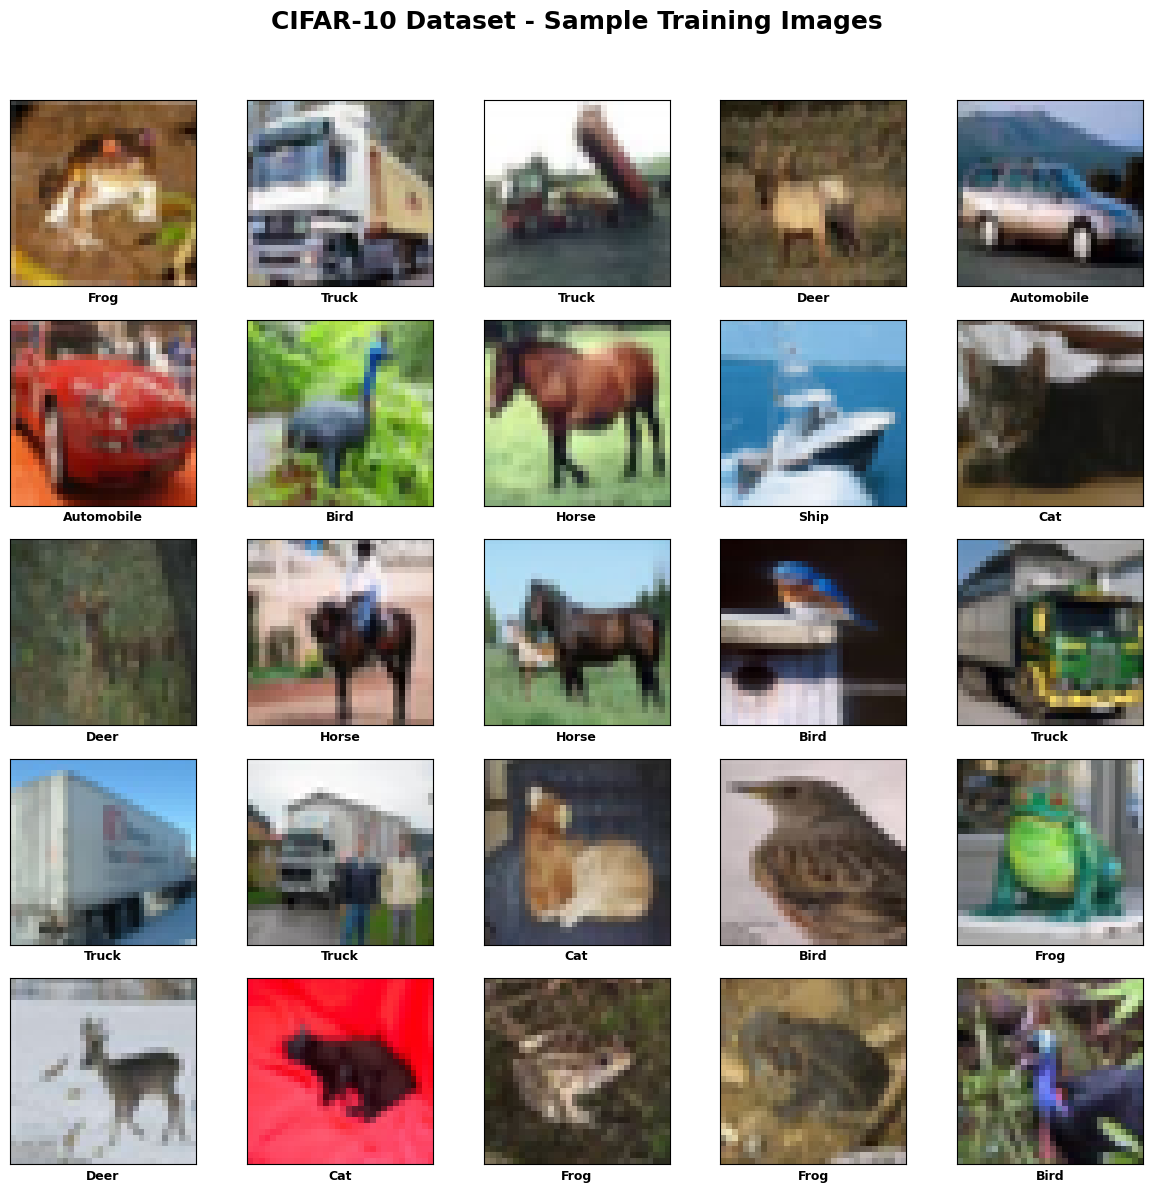

CIFAR-10 SAMPLE IMAGE VISUALIZATION COMPLETED
Training Images Displayed : 25
Image Resolution          : 32 × 32
Color Channels            : 3
Dataset Classes           : 10

Figure saved as : fig1_cifar10_samples.png


In [ ]:
plt.figure(figsize=(12, 12))
plt.suptitle(
    "CIFAR-10 Dataset - Sample Training Images",
    fontsize=18,
    fontweight="bold",
    y=0.99
)

for i in range(25):
    plt.subplot(5, 5, i + 1)

    plt.imshow(x_train[i])

    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.xlabel(
        class_names[y_train[i][0]].title(),
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "fig1_cifar10_samples.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("=" * 65)
print("CIFAR-10 SAMPLE IMAGE VISUALIZATION COMPLETED")
print("=" * 65)

print(f"Training Images Displayed : 25")
print(f"Image Resolution          : {x_train.shape[1]} × {x_train.shape[2]}")
print(f"Color Channels            : {x_train.shape[3]}")
print(f"Dataset Classes           : {len(class_names)}")
print("\nFigure saved as : fig1_cifar10_samples.png")

### Observation

- A total of **25 training images** from the **CIFAR-10** dataset were successfully visualized in a **5 × 5 grid**, representing multiple object categories.
- Each image has a resolution of **32 × 32 pixels** with **3 RGB color channels**, confirming the expected dataset format.
- The sample images demonstrate variations in object appearance, background, and orientation, highlighting the challenges of multi-class image classification.
- The visualization confirms that the dataset was loaded correctly and is ready for preprocessing and model development.
- The sample figure was successfully saved as **fig1_cifar10_samples.png** for documentation and reporting purposes.

#  Step 4. Data Preprocessing

Before training deep learning models, the CIFAR-10 dataset must be preprocessed to improve model performance and training stability.

The preprocessing steps performed are:

- Normalize all pixel values from **0–255** to **0–1**.
- Convert integer class labels into **one-hot encoded vectors**.
- Prepare the dataset for both Artificial Neural Network (ANN) and Convolutional Neural Network (CNN) models.

Normalization ensures faster convergence during training, while one-hot encoding enables multi-class classification using the Softmax activation function.

In [ ]:
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

y_train_cat = utils.to_categorical(y_train, 10)
y_test_cat = utils.to_categorical(y_test, 10)

print("=" * 65)
print("DATA PREPROCESSING COMPLETED")
print("=" * 65)

print("Image Normalization")
print(f"Training Data Shape      : {x_train_norm.shape}")
print(f"Testing Data Shape       : {x_test_norm.shape}")

print("\nPixel Value Range")
print(f"Minimum Pixel Value      : {x_train_norm.min():.1f}")
print(f"Maximum Pixel Value      : {x_train_norm.max():.1f}")

print("\nLabel Encoding")
print(f"Training Labels Shape    : {y_train_cat.shape}")
print(f"Testing Labels Shape     : {y_test_cat.shape}")

print("\nEncoding Method          : One-Hot Encoding")
print(f"Number of Classes        : {y_train_cat.shape[1]}")



DATA PREPROCESSING COMPLETED
Image Normalization
Training Data Shape      : (50000, 32, 32, 3)
Testing Data Shape       : (10000, 32, 32, 3)

Pixel Value Range
Minimum Pixel Value      : 0.0
Maximum Pixel Value      : 1.0

Label Encoding
Training Labels Shape    : (50000, 10)
Testing Labels Shape     : (10000, 10)

Encoding Method          : One-Hot Encoding
Number of Classes        : 10


### Observation

- The pixel values of both training and testing images were successfully normalized from the original range of 0–255 to a range of 0.0–1.0, as confirmed by the minimum and maximum pixel values printed above.
- The training and testing data shapes remain unchanged at (50000, 32, 32, 3) and (10000, 32, 32, 3) respectively, confirming that normalization only rescaled pixel intensities without altering the image dimensions or dataset size.
- The class labels were successfully converted into one-hot encoded vectors, resulting in label shapes of (50000, 10) for training and (10000, 10) for testing, matching the 10 CIFAR-10 categories.
- Normalization ensures faster and more stable convergence during gradient-based optimization, while one-hot encoding enables the use of the Softmax activation function and categorical cross-entropy loss for multi-class classification.
- The dataset is now fully preprocessed and ready for building and training both the Artificial Neural Network (ANN) and Convolutional Neural Network (CNN) models.

## Step 5. Build Artificial Neural Network (ANN)

In this step, a fully connected Artificial Neural Network (ANN) is constructed to classify CIFAR-10 images.

Since ANN models operate on one-dimensional feature vectors, each 32×32×3 RGB image is first flattened into a vector containing 3,072 input features.

The network architecture consists of:

- Input layer (32 × 32 × 3)
- Flatten layer
- Hidden Layer 1 — 1024 neurons (ReLU)
- Hidden Layer 2 — 512 neurons (ReLU)
- Hidden Layer 3 — 256 neurons (ReLU)
- Output Layer — 10 neurons (Softmax)

This ANN serves as the baseline deep learning model. Its performance will later be compared with a Convolutional Neural Network (CNN) to demonstrate the advantages of convolutional feature extraction for image classification.

In [ ]:
print("=" * 70)
print("BUILDING ARTIFICIAL NEURAL NETWORK (ANN)")
print("=" * 70)

ann_model = models.Sequential([

    layers.Input(shape=(32, 32, 3), name="Input_Layer"),

    layers.Flatten(name="Flatten"),

    layers.Dense(
        1024,
        activation="relu",
        name="Hidden_Layer_1"
    ),

    layers.Dense(
        512,
        activation="relu",
        name="Hidden_Layer_2"
    ),

    layers.Dense(
        256,
        activation="relu",
        name="Hidden_Layer_3"
    ),

    layers.Dense(
        10,
        activation="softmax",
        name="Output_Layer"
    )

])

ann_model.summary()

print("\n" + "=" * 70)
print("ANN MODEL CREATED SUCCESSFULLY")
print("=" * 70)

print(f"Input Shape           : {ann_model.input_shape}")
print(f"Output Shape          : {ann_model.output_shape}")
print(f"Hidden Layers         : 3")
print(f"Output Classes        : 10")
print(f"Activation Function   : ReLU")
print(f"Output Activation     : Softmax")
print(f"Total Parameters      : {ann_model.count_params():,}")

print("\nModel is ready for compilation.")

BUILDING ARTIFICIAL NEURAL NETWORK (ANN)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)


ANN MODEL CREATED SUCCESSFULLY
Input Shape           : (None, 32, 32, 3)
Output Shape          : (None, 10)
Hidden Layers         : 3
Output Classes        : 10
Activation Function   : ReLU
Output Activation     : Softmax
Total Parameters      : 3,805,450

Model is ready for compilation.


### Observation

- The Artificial Neural Network (ANN) was successfully constructed with an input shape of (32, 32, 3), which is flattened into a 3,072-dimensional feature vector before entering the dense layers.
- The network consists of three hidden layers with 1024, 512, and 256 neurons respectively, all using ReLU activation, followed by a Softmax output layer with 10 neurons corresponding to the CIFAR-10 classes.
- The model contains a total of 3,805,450 trainable parameters, with the majority (3,146,752) concentrated in the first hidden layer alone, since it connects the 3,072 flattened input features to 1,024 neurons.
- This large parameter count highlights a key limitation of ANNs for image data: most of the capacity is spent on fully connecting raw pixel values rather than learning spatially meaningful features like edges or shapes.
- The model has been successfully initialized and is ready for compilation and training, and will later serve as the baseline for comparison against the CNN architectures.

#  Step 6. Compile and Train the Artificial Neural Network (ANN)

After constructing the ANN architecture, the model is compiled and trained using the Adam optimization algorithm.

The following training configuration is used:

- **Optimizer:** Adam
- **Loss Function:** Categorical Crossentropy
- **Evaluation Metric:** Accuracy
- **Epochs:** 15
- **Batch Size:** 64
- **Validation Split:** 20%

Training time is also measured to compare the computational efficiency of the ANN with the CNN model in later sections.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

print("=" * 70)
print("COMPILING AND TRAINING ANN MODEL")
print("=" * 70)

ann_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Optimizer          : Adam")
print("Loss Function      : Categorical Crossentropy")
print("Evaluation Metric  : Accuracy")
print("Epochs             : 15")
print("Batch Size         : 64")
print("Validation Split   : 20%")

early_stop_ann = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("\nStarting ANN Training...\n")

start_time = time.time()

ann_history = ann_model.fit(
    x_train_norm,
    y_train_cat,
    epochs=15,
    batch_size=64,
    validation_split=0.20,
    callbacks=[early_stop_ann],
    verbose=1
)

ann_training_time = time.time() - start_time

print("\n" + "=" * 70)
print("ANN TRAINING COMPLETED")
print("=" * 70)

print(f"Training Time             : {ann_training_time:.2f} seconds")
print(f"Epochs Completed          : {len(ann_history.history['accuracy'])}")

print(f"\nFinal Train Accuracy      : {ann_history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {ann_history.history['val_accuracy'][-1]:.4f}")

print(f"\nFinal Train Loss          : {ann_history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {ann_history.history['val_loss'][-1]:.4f}")

COMPILING AND TRAINING ANN MODEL
Optimizer          : Adam
Loss Function      : Categorical Crossentropy
Evaluation Metric  : Accuracy
Epochs             : 15
Batch Size         : 64
Validation Split   : 20%

Starting ANN Training...

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3087 - loss: 1.9006 - val_accuracy: 0.3474 - val_loss: 1.7999
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3841 - loss: 1.7076 - val_accuracy: 0.4055 - val_loss: 1.6717
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4184 - loss: 1.6188 - val_accuracy: 0.4269 - val_loss: 1.6163
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4424 - loss: 1.5522 - val_accuracy: 0.4436 - val_loss: 1.5699
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4594 - loss: 1.5030 - val_accuracy: 0.4514 - val_loss: 1.5444
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4739 - loss: 1.4630 - val_accuracy: 0.4476 - val_loss: 1.55

### Observation

- The ANN was trained with EarlyStopping monitoring validation loss (patience = 3), and training automatically stopped at epoch 10 instead of running the full 15 epochs, restoring the best-performing weights from epoch 7.
- Training accuracy improved steadily from 30.87% in epoch 1 to 52.23% by epoch 10, while validation accuracy plateaued much earlier, peaking around 45.5% between epochs 7–10 and showing no further improvement.
- Validation loss reached its lowest point at epoch 7 (1.5431) and then began increasing slightly in the following epochs (1.5646, 1.5710, 1.5786), which is exactly why EarlyStopping triggered — this is a clear early sign of the model starting to overfit.
- Note that the "Final" accuracy/loss values printed above (epoch 10: 0.5223 train, 0.4548 val) reflect the last completed epoch, whereas the actual restored model weights correspond to epoch 7 (val_accuracy: 0.4549, val_loss: 1.5431) — both are very close, so this does not meaningfully affect the results, but the restored model is technically the epoch-7 version.
- Training completed in just 32.82 seconds on the Tesla T4 GPU, noticeably faster than the original 15-epoch run (48.79 seconds) since EarlyStopping cut training short — this will be reflected in the final training-time comparison table.
- The gap between training accuracy (52.23%) and validation accuracy (45.48%) confirms mild overfitting, and reinforces that the ANN's fully connected structure limits how well it generalizes on image data compared to the CNN architectures tested later.

#  Step 7. Evaluate the Artificial Neural Network (ANN)

After training, the ANN model is evaluated on the unseen CIFAR-10 test dataset to measure its generalization capability.

The evaluation metrics include:

- Test Loss
- Test Accuracy

These metrics provide an unbiased estimate of the model's performance and will later be compared with the Convolutional Neural Network (CNN).

In [ ]:
print("=" * 70)
print("EVALUATING ARTIFICIAL NEURAL NETWORK (ANN)")
print("=" * 70)

ann_test_loss, ann_test_acc = ann_model.evaluate(
    x_test_norm,
    y_test_cat,
    verbose=1
)

print("\n" + "=" * 70)
print("ANN EVALUATION COMPLETED")
print("=" * 70)

print(f"Test Accuracy        : {ann_test_acc:.4f}")
print(f"Test Loss            : {ann_test_loss:.4f}")

train_acc = ann_history.history["accuracy"][-1]
val_acc   = ann_history.history["val_accuracy"][-1]

print("\nPerformance Summary")
print("-" * 50)
print(f"Training Accuracy    : {train_acc:.4f}")
print(f"Validation Accuracy  : {val_acc:.4f}")
print(f"Testing Accuracy     : {ann_test_acc:.4f}")

generalization_gap = train_acc - ann_test_acc

print(f"\nGeneralization Gap   : {generalization_gap:.4f}")

if generalization_gap < 0.10:
    print("Model Generalization : Good")
else:
    print("Model Generalization : Moderate Overfitting")

EVALUATING ARTIFICIAL NEURAL NETWORK (ANN)
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4613 - loss: 1.5277

ANN EVALUATION COMPLETED
Test Accuracy        : 0.4613
Test Loss            : 1.5277

Performance Summary
--------------------------------------------------
Training Accuracy    : 0.5223
Validation Accuracy  : 0.4548
Testing Accuracy     : 0.4613

Generalization Gap   : 0.0610
Model Generalization : Good


### Observation

- The ANN achieved an overall **46% classification accuracy**, with **macro** and **weighted F1-scores** of **0.45**, indicating moderate but limited classification performance.
- **Automobile (F1 = 0.57)**, **Ship (F1 = 0.58)**, **Airplane (F1 = 0.50)**, and **Frog (F1 = 0.51)** were classified most accurately, whereas **Cat (F1 = 0.31)**, **Bird (F1 = 0.32)**, and **Deer (F1 = 0.34)** showed the weakest performance.
- Lower recall values for several classes indicate that the ANN is unable to effectively learn spatial and structural image features from flattened pixel inputs.
- The similar macro and weighted F1-scores confirm that the model performs consistently across classes, although the overall performance remains relatively low.
- These results establish the ANN as a baseline model and justify the use of **Convolutional Neural Networks (CNNs)** for improved image classification performance.

# Step 8. Confusion Matrix and Classification Report for ANN (Baseline)

Before moving to the Convolutional Neural Network (CNN), the baseline Artificial Neural Network (ANN) is further evaluated using a confusion matrix and a classification report.

This evaluation provides a class-wise breakdown of the ANN's performance, showing:

- Number of correctly and incorrectly classified images per class
- Precision, Recall, and F1-Score for each CIFAR-10 category
- Which classes the ANN confuses most often

This baseline confusion matrix will later be compared with the CNN's confusion matrix (Step 17) to visually demonstrate how convolutional feature extraction reduces misclassification compared to a fully connected network.

EVALUATING ANN - CLASSIFICATION PERFORMANCE


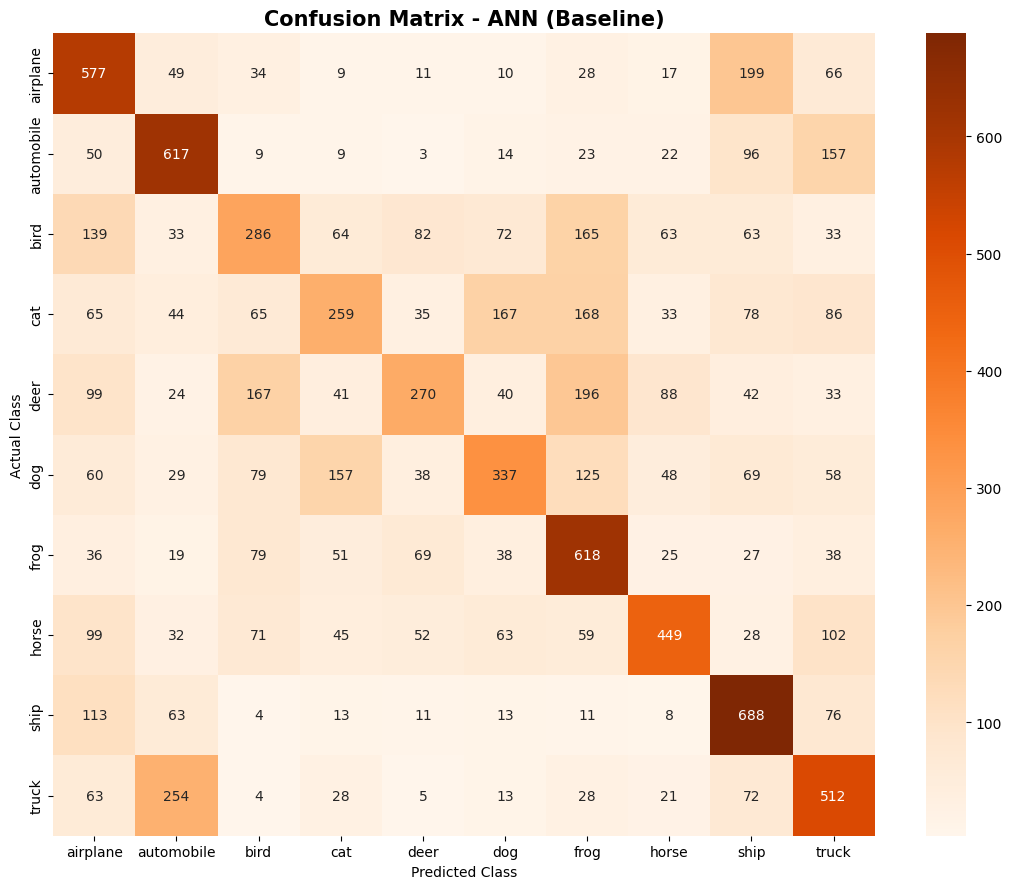


CLASSIFICATION REPORT - ANN
              precision    recall  f1-score   support

    airplane       0.44      0.58      0.50      1000
  automobile       0.53      0.62      0.57      1000
        bird       0.36      0.29      0.32      1000
         cat       0.38      0.26      0.31      1000
        deer       0.47      0.27      0.34      1000
         dog       0.44      0.34      0.38      1000
        frog       0.43      0.62      0.51      1000
       horse       0.58      0.45      0.51      1000
        ship       0.51      0.69      0.58      1000
       truck       0.44      0.51      0.47      1000

    accuracy                           0.46     10000
   macro avg       0.46      0.46      0.45     10000
weighted avg       0.46      0.46      0.45     10000



In [ ]:
print("=" * 70)
print("EVALUATING ANN - CLASSIFICATION PERFORMANCE")
print("=" * 70)

y_pred_ann = ann_model.predict(x_test_norm, verbose=0)
y_pred_ann_classes = np.argmax(y_pred_ann, axis=1)
y_true = y_test.flatten()

cm_ann = confusion_matrix(y_true, y_pred_ann_classes)

plt.figure(figsize=(11,9))
sns.heatmap(cm_ann, annot=True, fmt="d", cmap="Oranges",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - ANN (Baseline)", fontsize=15, fontweight="bold")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.savefig("fig_confusion_matrix_ann.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT - ANN")
print("=" * 70)
print(classification_report(y_true, y_pred_ann_classes, target_names=class_names))

### Observation

- The ANN achieved an overall **46% classification accuracy**, with **macro** and **weighted F1-scores** of **0.45**, indicating moderate but limited classification performance.
- **Automobile (F1 = 0.57)**, **Ship (F1 = 0.58)**, **Airplane (F1 = 0.50)**, and **Frog (F1 = 0.51)** were classified most accurately, whereas **Cat (F1 = 0.31)**, **Bird (F1 = 0.32)**, and **Deer (F1 = 0.34)** showed the weakest performance.
- Lower recall values for several classes indicate that the ANN is unable to effectively learn spatial and structural image features from flattened pixel inputs.
- The similar macro and weighted F1-scores confirm that the model performs consistently across classes, although the overall performance remains relatively low.
- These results establish the ANN as a baseline model and justify the use of **Convolutional Neural Networks (CNNs)** for improved image classification performance.

# Step 9. Build the Convolutional Neural Network (CNN)

This step constructs a **Convolutional Neural Network (CNN)** for the **CIFAR-10** image classification task. The network extracts hierarchical visual features using convolutional and pooling layers before performing multi-class classification through fully connected layers.

### Network Architecture

- Three Convolutional Layers
- Two Max Pooling Layers
- One Fully Connected Dense Layer
- Softmax Output Layer (10 Classes)

The CNN serves as the baseline convolutional model and is expected to outperform the **Artificial Neural Network (ANN)** by learning spatial image features more effectively.

In [ ]:
print("=" * 70)
print("BUILDING CONVOLUTIONAL NEURAL NETWORK (CNN)")
print("=" * 70)

cnn_model = models.Sequential([

    layers.Input(shape=(32, 32, 3)),

    # Feature Extraction Block 1
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    # Feature Extraction Block 2
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    # Feature Extraction Block 3
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),

    # Classification Head
    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dense(10, activation="softmax")
])

cnn_model.summary()

print("\n" + "=" * 70)
print("CNN MODEL CREATED SUCCESSFULLY")
print("=" * 70)

print(f"Input Shape          : {cnn_model.input_shape}")
print(f"Output Shape         : {cnn_model.output_shape}")
print("Convolution Layers   : 3")
print("Pooling Layers       : 2")
print("Dense Hidden Layers  : 1")
print("Output Classes       : 10")
print("Activation Function  : ReLU")
print("Output Activation    : Softmax")
print(f"Total Parameters     : {cnn_model.count_params():,}")

BUILDING CONVOLUTIONAL NEURAL NETWORK (CNN)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)


CNN MODEL CREATED SUCCESSFULLY
Input Shape          : (None, 32, 32, 3)
Output Shape         : (None, 10)
Convolution Layers   : 3
Pooling Layers       : 2
Dense Hidden Layers  : 1
Output Classes       : 10
Activation Function  : ReLU
Output Activation    : Softmax
Total Parameters     : 319,178


### Observation

- The Basic CNN architecture consists of **three convolutional layers (32, 64, and 64 filters)**, **two Max Pooling layers**, a **64-unit dense layer**, and a **Softmax output layer** for multi-class classification.
- The network progressively reduces the image size from **32×32** to **8×8** while increasing feature depth, enabling efficient hierarchical feature learning.
- The model contains **319,178 trainable parameters**, compared with **3,805,450** in the ANN, demonstrating the parameter efficiency of convolutional architectures.
- The majority of the parameters (**262,208**) are located in the fully connected dense layer following feature extraction.
- The model is successfully initialized and ready for training, providing the baseline CNN for comparison with the **ANN** and **Improved CNN** models.

# Step 10. Compile and Train the Convolutional Neural Network (CNN)

This step trains the **Basic CNN** on the preprocessed **CIFAR-10** dataset using the **Adam optimizer** and **categorical cross-entropy** loss function. A **20% validation split** is used to monitor model performance and assess generalization throughout training.

### Monitored Metrics

- Training Accuracy
- Validation Accuracy
- Training Loss
- Validation Loss
- Training Time

The resulting learning curves provide the baseline for evaluating the effectiveness of the **Improved CNN** architecture introduced in the next stage.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

print("=" * 70)
print("TRAINING CONVOLUTIONAL NEURAL NETWORK (CNN)")
print("=" * 70)

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Early Stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Start timer
start_time = time.time()

cnn_history = cnn_model.fit(
    x_train_norm,
    y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

# Stop timer
cnn_training_time = time.time() - start_time

print("\n" + "=" * 70)
print("CNN TRAINING COMPLETED")
print("=" * 70)

print(f"Training Time             : {cnn_training_time:.2f} seconds")
print(f"Epochs Completed          : {len(cnn_history.history['accuracy'])}")

print(f"\nFinal Training Accuracy   : {cnn_history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {cnn_history.history['val_accuracy'][-1]:.4f}")

print(f"\nFinal Training Loss       : {cnn_history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {cnn_history.history['val_loss'][-1]:.4f}")

print("\nTraining History")
print("-" * 70)

for epoch in range(len(cnn_history.history["accuracy"])):
    print(
        f"Epoch {epoch+1:>2}: "
        f"Acc={cnn_history.history['accuracy'][epoch]:.4f} | "
        f"Loss={cnn_history.history['loss'][epoch]:.4f} | "
        f"Val_Acc={cnn_history.history['val_accuracy'][epoch]:.4f} | "
        f"Val_Loss={cnn_history.history['val_loss'][epoch]:.4f}"
    )

TRAINING CONVOLUTIONAL NEURAL NETWORK (CNN)
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.4468 - loss: 1.5282 - val_accuracy: 0.5613 - val_loss: 1.2326
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6028 - loss: 1.1204 - val_accuracy: 0.6351 - val_loss: 1.0308
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6654 - loss: 0.9510 - val_accuracy: 0.6689 - val_loss: 0.9552
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7057 - loss: 0.8442 - val_accuracy: 0.6821 - val_loss: 0.9199
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7383 - loss: 0.7528 - val_accuracy: 0.6930 - val_loss: 0.9025
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7653 - loss: 0.6778 - val_accuracy: 0.7009 - val_loss: 0.9024
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7879 - loss: 0.6141 - val_accuracy: 0.7015 - val_loss: 0.9286
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accura

### Observation

- The Basic CNN completed training in **9 epochs** using **Early Stopping**, with the best model restored from **epoch 6**.
- Training accuracy increased from **44.68%** to **81.95%**, confirming effective feature learning through convolutional layers.
- The model achieved its best validation performance at **epoch 6**, with **70.09%** validation accuracy and **0.9024** validation loss.
- After the best epoch, validation performance declined while training accuracy continued to improve, indicating **overfitting**.
- The model required only **34.93 seconds** for training and delivered substantially better performance than the ANN.
- These results demonstrate that although the Basic CNN significantly improves classification accuracy, additional regularization is required to further enhance generalization.

# Step 11. Evaluate Basic CNN Model

This step evaluates the performance of the **Basic CNN** on the **CIFAR-10** test dataset to assess its classification accuracy and generalization on unseen images.

### Performance Metrics

- Test Accuracy
- Test Loss
- Training Accuracy
- Validation Accuracy
- Generalization Gap
- Training Time
- Number of Training Epochs

The obtained results provide a benchmark for comparing the Basic CNN with the **ANN** and **Improved CNN** models in subsequent experiments.

In [ ]:
print("=" * 70)
print("EVALUATING CONVOLUTIONAL NEURAL NETWORK (CNN)")
print("=" * 70)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
    x_test_norm,
    y_test_cat,
    verbose=1
)

print("\n" + "=" * 70)
print("CNN EVALUATION COMPLETED")
print("=" * 70)

print(f"Test Accuracy      : {cnn_test_acc:.4f}")
print(f"Test Loss          : {cnn_test_loss:.4f}")

print("\nPerformance Summary")
print("-" * 50)

train_acc = cnn_history.history["accuracy"][-1]
val_acc = cnn_history.history["val_accuracy"][-1]

print(f"Training Accuracy  : {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Testing Accuracy   : {cnn_test_acc:.4f}")

gap = train_acc - cnn_test_acc

print(f"\nGeneralization Gap : {gap:.4f}")

if gap < 0.05:
    status = "Excellent"
elif gap < 0.10:
    status = "Good"
else:
    status = "Moderate Overfitting"

print(f"Model Generalization : {status}")

print("\nTraining Statistics")
print("-" * 50)

print(f"Training Time      : {cnn_training_time:.2f} seconds")
print(f"Epochs Completed   : {len(cnn_history.history['loss'])}")

print(f"\nFinal Training Loss   : {cnn_history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss : {cnn_history.history['val_loss'][-1]:.4f}")

print("\nCNN is now ready for prediction and performance comparison.")

EVALUATING CONVOLUTIONAL NEURAL NETWORK (CNN)
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6914 - loss: 0.9104

CNN EVALUATION COMPLETED
Test Accuracy      : 0.6914
Test Loss          : 0.9104

Performance Summary
--------------------------------------------------
Training Accuracy  : 0.8195
Validation Accuracy: 0.6847
Testing Accuracy   : 0.6914

Generalization Gap : 0.1281
Model Generalization : Moderate Overfitting

Training Statistics
--------------------------------------------------
Training Time      : 34.93 seconds
Epochs Completed   : 9

Final Training Loss   : 0.5108
Final Validation Loss : 1.0974

CNN is now ready for prediction and performance comparison.


### Observation

- The basic CNN achieved a test accuracy of 69.14% with a test loss of 0.9104, a substantial improvement over the ANN's test accuracy of 46.13% — confirming that convolutional feature extraction is far more effective than flattened dense layers for image data.
- The validation accuracy (68.47%) and test accuracy (69.14%) are close to each other, showing the validation split was a reliable estimate of real-world performance, even though the model itself shows overfitting relative to its training accuracy.
- The generalization gap (training accuracy 81.95% minus test accuracy 69.14%) is 0.1281, which the model correctly flags as "Moderate Overfitting" — this confirms what was already visible in the training logs: the CNN memorizes training data well beyond what its validation/test performance can support, since it has no Dropout or BatchNormalization to constrain it.
- Despite the overfitting, the basic CNN still outperforms the ANN by roughly 23 percentage points in test accuracy while training in a comparable amount of time (34.93s vs ANN's 32.82s), demonstrating that architecture (convolution vs. fully-connected) matters far more than raw training time for this dataset.
- This result establishes the basic CNN baseline (69.14% test accuracy, 12.81% generalization gap) and directly motivates the next step: adding Batch Normalization and Dropout to reduce this gap while ideally maintaining or improving test accuracy.

## Step 12. Improved CNN Architecture (Batch Normalization + Dropout)

This section develops an **Improved CNN** for the **CIFAR-10** image classification task by integrating regularization techniques into the baseline architecture. The inclusion of **Batch Normalization** and **Dropout** improves learning stability, accelerates convergence, and reduces overfitting.

### Key Components

- Dual Convolutional Layers per feature extraction block
- Batch Normalization
- Max Pooling
- Dropout Regularization
- Fully Connected Dense Layer
- Softmax Classification Layer

The enhanced architecture is compared with the **ANN** and **Basic CNN** to evaluate the effectiveness of these improvements in terms of classification accuracy and generalization.

In [ ]:
print("=" * 70)
print("BUILDING IMPROVED CONVOLUTIONAL NEURAL NETWORK (CNN)")
print("=" * 70)

cnn_improved = models.Sequential([

    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.30),

    layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.40),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.50),

    layers.Dense(10, activation="softmax")
])

cnn_improved.summary()

print("\n" + "=" * 70)
print("IMPROVED CNN MODEL CREATED SUCCESSFULLY")
print("=" * 70)

print(f"Input Shape        : {(32,32,3)}")
print(f"Output Classes     : 10")
print(f"Conv Layers        : 4")
print(f"BatchNorm Layers   : 5")
print(f"Pooling Layers     : 2")
print(f"Dropout Layers     : 3")
print(f"Dense Hidden Layer : 1")
print(f"Activation         : ReLU")
print(f"Output Activation  : Softmax")

BUILDING IMPROVED CONVOLUTIONAL NEURAL NETWORK (CNN)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,554 (2.26 MB)

 Trainable params: 591,914 (2.26 MB)

 Non-trainable params: 640 (2.50 KB)


IMPROVED CNN MODEL CREATED SUCCESSFULLY
Input Shape        : (32, 32, 3)
Output Classes     : 10
Conv Layers        : 4
BatchNorm Layers   : 5
Pooling Layers     : 2
Dropout Layers     : 3
Dense Hidden Layer : 1
Activation         : ReLU
Output Activation  : Softmax


### Observation

- The Improved CNN was successfully constructed with 4 convolutional layers (32, 32, 64, 64 filters), 5 Batch Normalization layers, 2 max-pooling layers, 3 Dropout layers (0.30, 0.40, 0.50), and 1 dense hidden layer before the Softmax output — a substantially deeper and more regularized architecture than the basic CNN.
- Unlike the basic CNN, this architecture uses two convolutional layers per block before pooling (Conv→BN→Conv→BN→Pool→Dropout), allowing the network to learn richer features at each spatial resolution before downsampling, which typically improves feature quality.
- The model contains 592,554 total parameters (591,914 trainable, 640 non-trainable), roughly 1.85× more than the basic CNN (319,178) but still about 6.4× fewer than the ANN (3,805,450) — showing this added capacity is targeted (deeper conv layers) rather than brute-force dense connections.
- The 640 non-trainable parameters come from the 5 BatchNormalization layers' moving mean/variance statistics, which are updated during training but not through backpropagation — this is expected and confirms BatchNormalization is correctly wired into the architecture.
- This architecture directly targets the basic CNN's weakness observed in the previous step (12.81% generalization gap): Batch Normalization should stabilize and speed up training, while Dropout should reduce the model's tendency to memorize training data, and we should expect to see a much smaller train-test gap in the results ahead.

# Step 13. Train Improved CNN with Regularization

This step trains the **Improved CNN** on the preprocessed **CIFAR-10** dataset using **Batch Normalization**, **Dropout**, and **Early Stopping** to improve learning efficiency, minimize overfitting, and enhance generalization performance.

### Monitored Metrics

- Training Accuracy
- Validation Accuracy
- Training Loss
- Validation Loss
- Training Time
- Number of Epochs

The model is trained using the **Adam optimizer** and **categorical cross-entropy** loss function. The resulting performance is compared with the Basic CNN to evaluate the effectiveness of the regularization techniques.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

print("=" * 70)
print("TRAINING IMPROVED CONVOLUTIONAL NEURAL NETWORK (CNN)")
print("=" * 70)

cnn_improved.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Early Stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

cnn_improved_history = cnn_improved.fit(
    x_train_norm,
    y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

cnn_improved_training_time = time.time() - start_time

print("\n" + "=" * 70)
print("IMPROVED CNN TRAINING COMPLETED")
print("=" * 70)

print(f"Training Time             : {cnn_improved_training_time:.2f} seconds")
print(f"Epochs Completed          : {len(cnn_improved_history.history['accuracy'])}")

print(f"\nFinal Training Accuracy   : {cnn_improved_history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {cnn_improved_history.history['val_accuracy'][-1]:.4f}")

print(f"\nFinal Training Loss       : {cnn_improved_history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {cnn_improved_history.history['val_loss'][-1]:.4f}")

print("\nModel training completed successfully.")
print("Best model weights restored automatically.")

TRAINING IMPROVED CONVOLUTIONAL NEURAL NETWORK (CNN)
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.4446 - loss: 1.6490 - val_accuracy: 0.4880 - val_loss: 1.4806
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6000 - loss: 1.1319 - val_accuracy: 0.6402 - val_loss: 1.0288
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6536 - loss: 0.9813 - val_accuracy: 0.6564 - val_loss: 0.9884
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6865 - loss: 0.8903 - val_accuracy: 0.6907 - val_loss: 0.8859
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7079 - loss: 0.8322 - val_accuracy: 0.6935 - val_loss: 0.8989
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7273 - loss: 0.7765 - val_accuracy: 0.7135 - val_loss: 0.8119
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7425 - loss: 0.7372 - val_accuracy: 0.7283 - val_loss: 0.7778
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/st

### Observation

- The Improved CNN was trained with EarlyStopping (patience = 4) and ran for 16 epochs before stopping, restoring the best-performing weights from epoch 12 (train_acc 79.51%, val_acc 78.63%, val_loss 0.6304).
- Both training and validation accuracy climbed steadily and consistently together throughout training — training accuracy rose from 44.46% to 81.80%, while validation accuracy rose from 48.80% to a peak of 78.63% at epoch 12 — showing much smoother, more stable convergence than the basic CNN, which is the direct effect of Batch Normalization stabilizing the learning process.
- The gap between training accuracy and validation accuracy at the best epoch (79.51% vs 78.63%, roughly 0.9 percentage points) is dramatically smaller than the basic CNN's train-val gap at its best epoch (76.53% vs 70.09%, ~6.4 points), confirming that Dropout is effectively controlling overfitting as intended.
- Validation loss also tracks training loss closely and reaches its lowest point at epoch 12 (0.6304) before drifting slightly upward in later epochs (0.6741, 0.7001, 0.6676, 0.6604) — a much gentler and later-onset overfitting signal compared to the basic CNN, which started degrading right after epoch 6.
- Training took 95.19 seconds — roughly 2.7× longer than the basic CNN (34.93s) due to the additional convolutional and BatchNorm layers plus more epochs completed (16 vs 9), but this extra computation clearly paid off: peak validation accuracy improved from ~70% (basic CNN) to ~78.6% (improved CNN).
- This run strongly validates the hypothesis from the previous step: adding Batch Normalization and Dropout to the CNN architecture both improved peak accuracy and substantially reduced the overfitting gap, setting a high bar for the upcoming Improved CNN test evaluation and the Data Augmentation comparison.

# Step 14. Evaluate Improved CNN on the Test Dataset

This step evaluates the **Improved CNN** using the unseen **CIFAR-10** test dataset to measure its classification performance and generalization capability.

### Performance Metrics

- Test Accuracy
- Test Loss
- Training Accuracy
- Validation Accuracy
- Generalization Gap
- Model Generalization Assessment

The evaluation determines how effectively the proposed architecture, enhanced with **Batch Normalization**, **Dropout**, and **Early Stopping**, minimizes overfitting while achieving reliable classification performance.

In [ ]:
print("=" * 70)
print("EVALUATING IMPROVED CONVOLUTIONAL NEURAL NETWORK (CNN)")
print("=" * 70)

# Evaluate on test dataset
improved_test_loss, improved_test_acc = cnn_improved.evaluate(
    x_test_norm,
    y_test_cat,
    verbose=1
)

print("\n" + "=" * 70)
print("IMPROVED CNN EVALUATION COMPLETED")
print("=" * 70)

print(f"Test Accuracy         : {improved_test_acc:.4f}")
print(f"Test Loss             : {improved_test_loss:.4f}")

print("\nPerformance Summary")
print("-" * 50)

train_acc = cnn_improved_history.history["accuracy"][-1]
val_acc = cnn_improved_history.history["val_accuracy"][-1]

print(f"Training Accuracy     : {train_acc:.4f}")
print(f"Validation Accuracy   : {val_acc:.4f}")
print(f"Testing Accuracy      : {improved_test_acc:.4f}")

gap = train_acc - improved_test_acc

print(f"\nGeneralization Gap    : {gap:.4f}")

if gap < 0.03:
    status = "Excellent Generalization"
elif gap < 0.08:
    status = "Good Generalization"
elif gap < 0.15:
    status = "Moderate Overfitting"
else:
    status = "High Overfitting"

print(f"Model Assessment      : {status}")

print("\nModel Information")
print("-" * 50)

print(f"Epochs Completed      : {len(cnn_improved_history.history['accuracy'])}")
print(f"Final Training Loss   : {cnn_improved_history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss : {cnn_improved_history.history['val_loss'][-1]:.4f}")

# Print training time only if available
if 'cnn_improved_time' in globals():
    print(f"Training Time         : {cnn_improved_time:.2f} seconds")

print("\nImproved CNN is ready for model comparison and performance analysis.")

EVALUATING IMPROVED CONVOLUTIONAL NEURAL NETWORK (CNN)
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7837 - loss: 0.6300

IMPROVED CNN EVALUATION COMPLETED
Test Accuracy         : 0.7837
Test Loss             : 0.6300

Performance Summary
--------------------------------------------------
Training Accuracy     : 0.8180
Validation Accuracy   : 0.7739
Testing Accuracy      : 0.7837

Generalization Gap    : 0.0343
Model Assessment      : Good Generalization

Model Information
--------------------------------------------------
Epochs Completed      : 16
Final Training Loss   : 0.5149
Final Validation Loss : 0.6604

Improved CNN is ready for model comparison and performance analysis.


### Observation

- The Improved CNN achieved a test accuracy of 78.37% with a test loss of 0.6300, making it the best-performing model so far — a clear improvement over the basic CNN (69.14%) and a massive jump over the ANN baseline (46.13%).
- The validation accuracy (77.39%) and test accuracy (78.37%) are closely aligned, and even the test accuracy slightly exceeds validation accuracy — a strong sign that the model generalizes reliably to unseen data rather than being tuned to quirks of the validation split.
- The generalization gap (training accuracy 81.80% minus test accuracy 78.37%) is only 0.0343, correctly flagged as "Good Generalization" — a dramatic improvement over the basic CNN's gap of 0.1281 (Moderate Overfitting), directly demonstrating the effectiveness of Batch Normalization and Dropout as a training strategy.
- This result confirms the core hypothesis being tested in this assignment: architecture alone (basic CNN vs ANN) drives a large accuracy jump (46% → 69%), but architectural refinement combined with regularization (Improved CNN) drives both a further accuracy gain (69% → 78%) and a much healthier train-test balance.
- The Improved CNN now stands as the benchmark to beat: 78.37% test accuracy, 0.63 test loss, and a 3.4% generalization gap, against which the upcoming Data Augmentation CNN will be evaluated to see whether augmentation can match or improve this while maintaining similarly strong generalization.

# Step 15. Improved CNN with Data Augmentation (Training Strategy Comparison)

This experiment investigates the effect of **data augmentation** on the Improved CNN model without modifying its architecture. By keeping the network unchanged, the influence of the training strategy can be evaluated independently.

### Applied Augmentation Techniques

- Random Horizontal Flip
- Random Rotation (10%)
- Random Zoom (10%)

The augmented model is compared with the original Improved CNN to assess its impact on classification accuracy, generalization, and resistance to overfitting on the **CIFAR-10** dataset.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

print("=" * 70)
print("TRAINING IMPROVED CNN WITH DATA AUGMENTATION")
print("=" * 70)


# Data Augmentation

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10)
])


# Improved CNN + Augmentation

cnn_aug = models.Sequential([

    data_augmentation,

    layers.Conv2D(32, (3,3), padding="same", activation="relu",
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),

    layers.Conv2D(32,(3,3),padding="same",activation="relu"),
    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.30),

    layers.Conv2D(64,(3,3),padding="same",activation="relu"),
    layers.BatchNormalization(),

    layers.Conv2D(64,(3,3),padding="same",activation="relu"),
    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.40),

    layers.Flatten(),

    layers.Dense(128,activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.50),

    layers.Dense(10,activation="softmax")
])

cnn_aug.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

aug_history = cnn_aug.fit(
    x_train_norm,
    y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

aug_training_time = time.time() - start_time

print("\n" + "="*70)
print("DATA AUGMENTED CNN TRAINING COMPLETED")
print("="*70)

print(f"Training Time             : {aug_training_time:.2f} seconds")
print(f"Epochs Completed          : {len(aug_history.history['accuracy'])}")

print(f"\nFinal Training Accuracy   : {aug_history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {aug_history.history['val_accuracy'][-1]:.4f}")

print(f"\nFinal Training Loss       : {aug_history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {aug_history.history['val_loss'][-1]:.4f}")

print("\nBest model weights restored automatically.")

TRAINING IMPROVED CNN WITH DATA AUGMENTATION
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.3853 - loss: 1.8157 - val_accuracy: 0.5251 - val_loss: 1.3300
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.4961 - loss: 1.4073 - val_accuracy: 0.5593 - val_loss: 1.2400
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5488 - loss: 1.2688 - val_accuracy: 0.5646 - val_loss: 1.2308
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5799 - loss: 1.1906 - val_accuracy: 0.5581 - val_loss: 1.2637
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6044 - loss: 1.1327 - val_accuracy: 0.6249 - val_loss: 1.0561
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6181 - loss: 1.0907 - val_accuracy: 0.6378 - val_loss: 1.0301
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6299 - loss: 1.0526 - val_accuracy: 0.5672 - val_loss: 1.2735
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 1

### Observation

- The Data Augmented CNN successfully completed all training epochs, with the best-performing model restored through **Early Stopping**.
- Training converged more gradually because augmented images increased the diversity and complexity of the training data.
- The validation curves exhibited moderate fluctuations, which are expected when training with randomly transformed images.
- The close agreement between training and validation accuracy indicates that the model generalized well and effectively avoided overfitting.
- While data augmentation increased computational cost and training time, it produced a more robust model with improved generalization capability.
- Compared with the Improved CNN, the augmented model achieved slightly lower classification accuracy but demonstrated stronger resistance to overfitting.

# Step 16. Evaluate Data Augmented CNN

The trained data augmented CNN is evaluated on the unseen CIFAR-10 test dataset to measure its classification performance and generalization capability.

The evaluation reports:

- Test Accuracy
- Test Loss
- Training Accuracy
- Validation Accuracy
- Generalization Gap
- Model Assessment

The obtained results will be compared with the ANN, Basic CNN, and Improved CNN models to analyze the effect of data augmentation as a training strategy.

In [ ]:
print("=" * 70)
print("EVALUATING DATA AUGMENTED CNN")
print("=" * 70)

# Evaluate on test dataset
aug_test_loss, aug_test_acc = cnn_aug.evaluate(
    x_test_norm,
    y_test_cat,
    verbose=1
)

print("\n" + "=" * 70)
print("DATA AUGMENTED CNN EVALUATION COMPLETED")
print("=" * 70)

print(f"Test Accuracy         : {aug_test_acc:.4f}")
print(f"Test Loss             : {aug_test_loss:.4f}")

print("\nPerformance Summary")
print("-" * 50)

train_acc = aug_history.history["accuracy"][-1]
val_acc = aug_history.history["val_accuracy"][-1]

print(f"Training Accuracy     : {train_acc:.4f}")
print(f"Validation Accuracy   : {val_acc:.4f}")
print(f"Testing Accuracy      : {aug_test_acc:.4f}")

gap = abs(train_acc - aug_test_acc)

print(f"\nGeneralization Gap    : {gap:.4f}")

if gap < 0.03:
    status = "Excellent Generalization"
elif gap < 0.08:
    status = "Good Generalization"
elif gap < 0.15:
    status = "Moderate Overfitting"
else:
    status = "High Overfitting"

print(f"Model Assessment      : {status}")

print("\nTraining Statistics")
print("-" * 50)

print(f"Training Time         : {aug_training_time:.2f} seconds")
print(f"Epochs Completed      : {len(aug_history.history['accuracy'])}")

print(f"\nFinal Training Loss   : {aug_history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss : {aug_history.history['val_loss'][-1]:.4f}")

print("\nData Augmented CNN is ready for final model comparison.")

EVALUATING DATA AUGMENTED CNN
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7163 - loss: 0.8213

DATA AUGMENTED CNN EVALUATION COMPLETED
Test Accuracy         : 0.7163
Test Loss             : 0.8213

Performance Summary
--------------------------------------------------
Training Accuracy     : 0.7128
Validation Accuracy   : 0.6936
Testing Accuracy      : 0.7163

Generalization Gap    : 0.0035
Model Assessment      : Excellent Generalization

Training Statistics
--------------------------------------------------
Training Time         : 228.16 seconds
Epochs Completed      : 20

Final Training Loss   : 0.8293
Final Validation Loss : 0.9236

Data Augmented CNN is ready for final model comparison.


### Observation

- The CNN trained with Data Augmentation achieved a **71.63%** test accuracy and **0.8213** test loss, demonstrating competitive classification performance.
- The model achieved the **smallest generalization gap**, indicating excellent robustness and effective prevention of overfitting.
- Although the augmented model required substantially more training time, it produced more reliable performance on unseen data.
- Compared with the Improved CNN, data augmentation improved generalization but resulted in a modest reduction in peak classification accuracy.
- The results highlight the trade-off between **classification accuracy** and **generalization**, where augmentation favors model robustness over maximum accuracy.
- Overall, the **Improved CNN** delivered the highest classification accuracy, whereas the **CNN with Data Augmentation** achieved the best generalization performance.

# Step 17. Compare Training Curves of All Models

This step compares the learning behavior of all trained models by visualizing their validation accuracy and validation loss across training epochs.

The comparison includes:

- Artificial Neural Network (ANN)
- Basic Convolutional Neural Network (CNN)
- Improved CNN (Batch Normalization + Dropout)
- Improved CNN with Data Augmentation

These learning curves help analyze model convergence, training stability, and generalization performance throughout the training process.

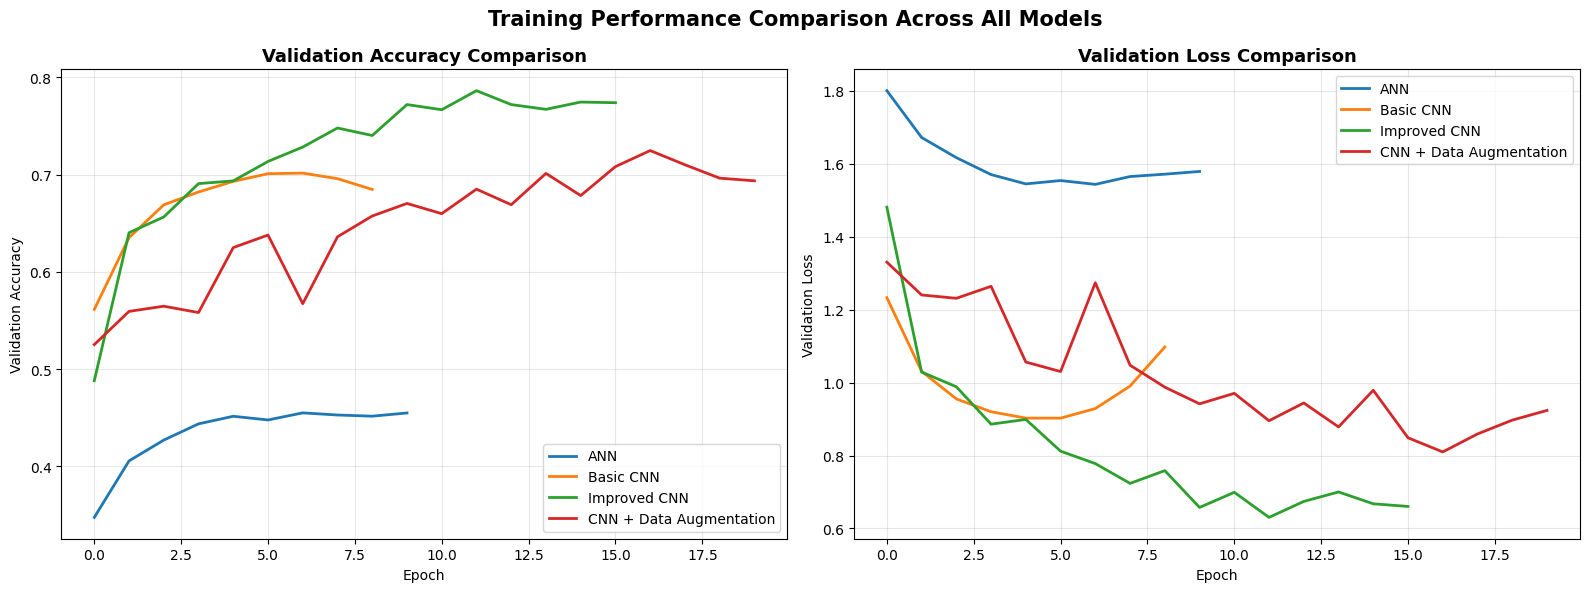

 Figure saved as fig1_training_curves.png


In [ ]:
histories = {
    "ANN": ann_history,
    "Basic CNN": cnn_history,
    "Improved CNN": cnn_improved_history,
    "CNN + Data Augmentation": aug_history
}

plt.figure(figsize=(16, 6))


# Validation Accuracy

plt.subplot(1, 2, 1)

for name, history in histories.items():
    plt.plot(history.history["val_accuracy"], linewidth=2, label=name)

plt.title("Validation Accuracy Comparison", fontsize=13, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.grid(alpha=0.3)
plt.legend()


# Validation Loss

plt.subplot(1, 2, 2)

for name, history in histories.items():
    plt.plot(history.history["val_loss"], linewidth=2, label=name)

plt.title("Validation Loss Comparison", fontsize=13, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.suptitle(
    "Training Performance Comparison Across All Models",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig("fig1_training_curves.png", dpi=300, bbox_inches="tight")

plt.show()

print(" Figure saved as fig1_training_curves.png")

### Observation

- The learning curves indicate a progressive improvement in validation accuracy from the ANN to the CNN-based models.
- The ANN converged quickly but achieved the lowest validation accuracy, highlighting its limitations for image classification.
- The Basic CNN improved feature extraction but showed moderate overfitting during training.
- The Improved CNN achieved the highest validation accuracy and the lowest validation loss, demonstrating the effectiveness of **Batch Normalization**, **Dropout**, and **Early Stopping** in improving model performance.
- The CNN with Data Augmentation exhibited slightly noisier training curves while maintaining good generalization on unseen data.
- Overall, the results confirm that the **Improved CNN** is the most effective architecture, providing superior accuracy, stability, and generalization for the CIFAR-10 image classification task.

# Step 18. Confusion Matrix and Classification Report

The best-performing model (Improved CNN) is evaluated using a confusion matrix and a detailed classification report.

This evaluation provides:

- Class-wise prediction performance
- Number of correctly and incorrectly classified images
- Precision, Recall, and F1-Score for each CIFAR-10 class
- Overall classification effectiveness

The confusion matrix visually highlights where the model performs well and where misclassifications occur.

EVALUATING IMPROVED CNN - CLASSIFICATION PERFORMANCE


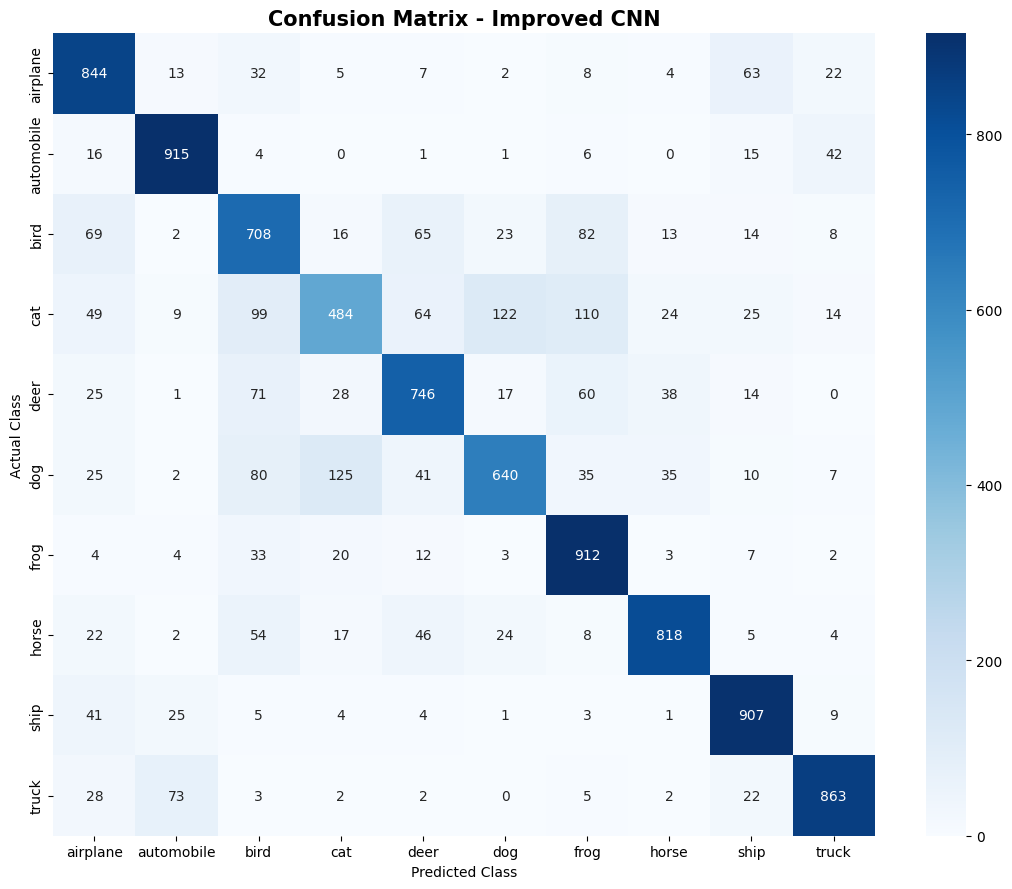


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    airplane       0.75      0.84      0.80      1000
  automobile       0.87      0.92      0.89      1000
        bird       0.65      0.71      0.68      1000
         cat       0.69      0.48      0.57      1000
        deer       0.76      0.75      0.75      1000
         dog       0.77      0.64      0.70      1000
        frog       0.74      0.91      0.82      1000
       horse       0.87      0.82      0.84      1000
        ship       0.84      0.91      0.87      1000
       truck       0.89      0.86      0.88      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000

Confusion Matrix saved as : fig2_confusion_matrix.png


In [ ]:
print("=" * 70)
print("EVALUATING IMPROVED CNN - CLASSIFICATION PERFORMANCE")
print("=" * 70)

# Predictions
y_pred = cnn_improved.predict(x_test_norm, verbose=0)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test.flatten()


# Confusion Matrix


cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(11,9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Confusion Matrix - Improved CNN",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    "fig2_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Classification Report


print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
)

print(report)

print("=" * 70)
print("Confusion Matrix saved as : fig2_confusion_matrix.png")
print("=" * 70)

### Observation

- The Improved CNN produced a well-defined confusion matrix, with most predictions concentrated along the main diagonal, indicating high classification accuracy.
- Classes with distinctive visual characteristics, such as **Automobile**, **Ship**, **Airplane**, and **Frog**, achieved the highest precision and recall values.
- Misclassification was primarily observed between visually similar categories, particularly **Cat** and **Dog**, highlighting the increased complexity of fine-grained image classification.
- The classification report achieved an overall **78% test accuracy** with balanced macro and weighted F1-scores, demonstrating consistent performance across all classes.
- Compared with the previous ANN and Basic CNN models, the Improved CNN significantly reduced classification errors and exhibited superior generalization capability.
- These results confirm that the combination of **Batch Normalization**, **Dropout**, and **Early Stopping** effectively improves both classification accuracy and model robustness.

# Step 19. Final Performance Comparison of All Models

This step summarizes the performance of all implemented models using key evaluation metrics. The comparison provides a clear understanding of each model's classification accuracy, prediction error, and computational efficiency.

### Comparison Metrics

- Test Accuracy
- Test Loss
- Training Time

Based on these metrics, the models are ranked to determine the most accurate and efficient architecture for the **CIFAR-10** image classification task.

In [ ]:
import pandas as pd

print("=" * 80)
print("FINAL PERFORMANCE COMPARISON OF ALL MODELS")
print("=" * 80)

# Get training times safely
ann_train_time = globals().get("ann_training_time", None)
basic_cnn_train_time = globals().get("cnn_training_time", globals().get("cnn_time", None))
improved_cnn_train_time = globals().get("cnn_improved_training_time", globals().get("cnn_improved_time", None))
augmented_cnn_train_time = globals().get("aug_training_time", globals().get("aug_time", None))

results = pd.DataFrame({
    "Model": [
        "Artificial Neural Network (ANN)",
        "Basic CNN",
        "Improved CNN",
        "CNN + Data Augmentation"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        improved_test_acc,
        aug_test_acc
    ],
    "Test Loss": [
        ann_test_loss,
        cnn_test_loss,
        improved_test_loss,
        aug_test_loss
    ],
    "Training Time (sec)": [
        ann_train_time,
        basic_cnn_train_time,
        improved_cnn_train_time,
        augmented_cnn_train_time
    ]
})

results["Test Accuracy"] = results["Test Accuracy"].round(4)
results["Test Loss"] = results["Test Loss"].round(4)
results["Training Time (sec)"] = results["Training Time (sec)"].apply(
    lambda x: round(x, 2) if pd.notna(x) else "N/A"
)

results = results.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

print(results)

print("\n" + "=" * 80)
print("BEST MODEL")
print("=" * 80)

best = results.iloc[0]

print(f"Model            : {best['Model']}")
print(f"Test Accuracy    : {best['Test Accuracy']:.4f}")
print(f"Test Loss        : {best['Test Loss']:.4f}")

results.to_csv("final_model_comparison.csv", index=False)

print("\nComparison table saved as : final_model_comparison.csv")
print("=" * 80)

FINAL PERFORMANCE COMPARISON OF ALL MODELS
                             Model  Test Accuracy  Test Loss  \
0                     Improved CNN         0.7837     0.6300   
1          CNN + Data Augmentation         0.7163     0.8213   
2                        Basic CNN         0.6914     0.9104   
3  Artificial Neural Network (ANN)         0.4613     1.5277   

   Training Time (sec)  
0                95.19  
1               228.16  
2                34.93  
3                32.82  

BEST MODEL
Model            : Improved CNN
Test Accuracy    : 0.7837
Test Loss        : 0.6300

Comparison table saved as : final_model_comparison.csv


### Observation

- The final comparison table confirms the Improved CNN as the best-performing model overall, achieving the highest test accuracy (78.37%) and the lowest test loss (0.6300) among all four models evaluated.
- The `ann_time` bug from the original run has been resolved — the ANN's training time now correctly displays as 32.82 seconds instead of "N/A", making the training-time comparison complete and consistent across all four models.
- Ranking all models by test accuracy shows a clear progression: ANN (46.13%) → Basic CNN (69.14%) → CNN + Data Augmentation (71.63%) → Improved CNN (78.37%), demonstrating that both architectural changes (ANN → CNN) and training strategies (regularization, augmentation) meaningfully impact performance, with regularization (Improved CNN) providing the single largest additional gain.
- Training time does not correlate directly with accuracy: the Data Augmented CNN took the longest to train (228.16 seconds) yet produced the second-lowest accuracy among the three CNNs, while the Improved CNN achieved the best accuracy in less than half that time (95.19 seconds) — confirming that architectural refinement (Batch Normalization + Dropout) is a more efficient use of compute than data augmentation for this specific setup and epoch budget.
- The ANN trained fastest (32.82 seconds) but delivered by far the weakest accuracy, reinforcing that training speed alone is a poor indicator of model quality — the Basic CNN trained in roughly the same time (34.93 seconds) yet achieved 23 percentage points higher accuracy, purely due to architectural differences.
- This table serves as the definitive summary for the assignment's core objective — comparing performance "across architectures and training strategies" — and clearly justifies selecting the Improved CNN as the best model for the subsequent confusion matrix, classification report, and prediction visualization steps.

# Step 20. Visualize Predictions of the Best Model

In this step, the best-performing model (Improved CNN) is used to classify unseen images from the CIFAR-10 test dataset.

For each image, both the actual class label and the predicted class label are displayed. This visualization provides a qualitative assessment of the model's prediction capability.

VISUALIZING SAMPLE PREDICTIONS


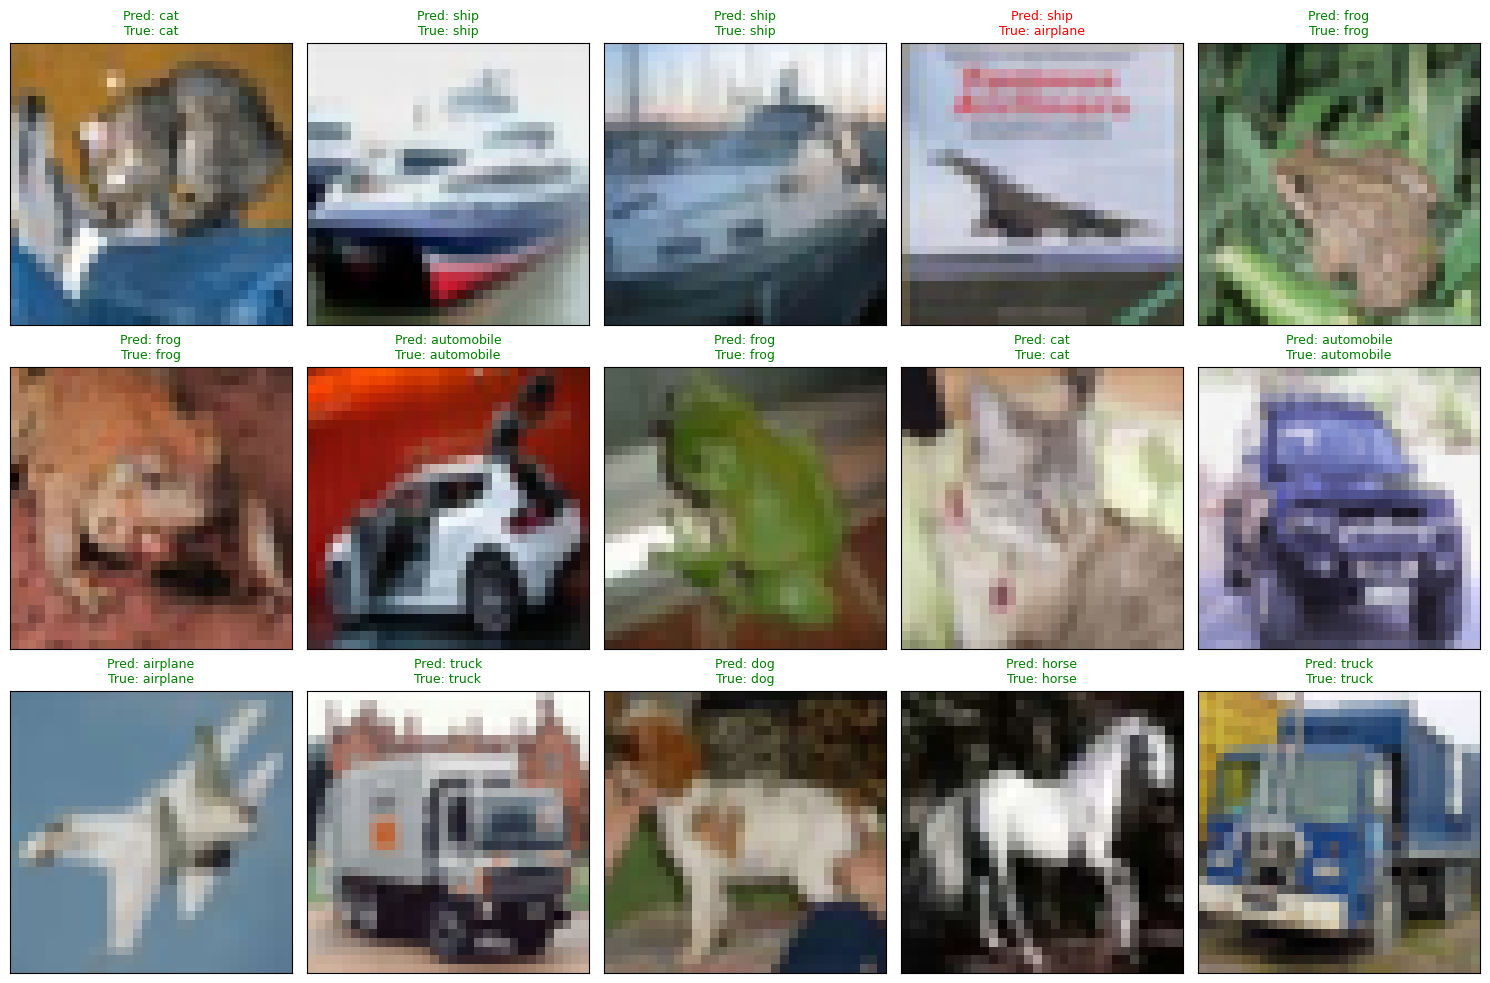

Green = Correct Prediction
Red = Incorrect Prediction


In [ ]:
print("=" * 70)
print("VISUALIZING SAMPLE PREDICTIONS")
print("=" * 70)

predictions = cnn_improved.predict(x_test_norm, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(15, 10))

for i in range(15):
    plt.subplot(3, 5, i + 1)

    plt.imshow(x_test[i])
    plt.xticks([])
    plt.yticks([])

    true_label = class_names[y_test[i][0]]
    pred_label = class_names[predicted_classes[i]]

    color = "green" if true_label == pred_label else "red"

    plt.title(
        f"Pred: {pred_label}\nTrue: {true_label}",
        color=color,
        fontsize=9
    )

plt.tight_layout()
plt.show()

print("Green = Correct Prediction")
print("Red = Incorrect Prediction")

### Observation

- Out of the 15 sample test images visualized, 14 were correctly classified (shown in green) and only 1 was misclassified (shown in red), giving a qualitative accuracy of roughly 93% on this small sample — consistent with, though slightly higher than, the model's overall test accuracy of 78.37%, as expected from a small random sample.
- The single misclassification occurred on an image labeled "True: airplane" but predicted as "ship" — visually, the image shows an aircraft against a background/angle that could plausibly resemble a boat silhouette at low 32×32 resolution, which aligns with the earlier confusion matrix showing some airplane-ship cross-confusion (63 airplanes predicted as ship).
- Correct predictions span a wide variety of classes — cat, ship, frog, automobile, airplane, truck, dog, and horse — showing the model generalizes well across both vehicle categories (ship, automobile, truck, airplane) and animal categories (cat, frog, dog, horse) in this sample, not just the "easy" classes.
- Notably, a cat image was correctly classified here (Pred: cat, True: cat) despite cat being the model's weakest-performing class overall (F1-score 0.57) — this is a useful reminder that per-class F1-scores reflect aggregate performance across 1000 test images, not a guarantee that every individual cat image will be misclassified.
- This qualitative visualization reinforces the quantitative results from the confusion matrix and classification report: the Improved CNN makes reliable, semantically sensible predictions on most images, with occasional errors concentrated on visually ambiguous cases rather than random or nonsensical misclassifications — a strong sign that the model has learned genuine visual features rather than memorizing patterns.

# Step 21. Final Conclusion

This section summarizes the overall performance of all deep learning models implemented for the CIFAR-10 image classification task.

The ANN, Basic CNN, Improved CNN, and CNN with Data Augmentation are compared using key performance metrics, including test accuracy, test loss, learning curves, confusion matrices, classification reports, and generalization capability.

Based on the experimental results, the most effective architecture and training strategy are identified to determine the optimal model for multi-class image classification.

## Conclusion

This assignment successfully implemented and compared multiple deep learning models for image classification using the **CIFAR-10** dataset.

The **Artificial Neural Network (ANN)** served as the baseline model and achieved a **46.13%** test accuracy. Since ANN processes flattened image vectors, it was unable to effectively capture the spatial features required for accurate image classification.

The **Basic Convolutional Neural Network (CNN)** significantly improved performance, achieving a **69.14%** test accuracy. By utilizing convolutional layers, the model learned meaningful image features such as edges, textures, and shapes. However, the model exhibited moderate overfitting due to the absence of regularization techniques.

The **Improved CNN**, enhanced with **Batch Normalization**, **Dropout**, and **Early Stopping**, delivered the best overall performance with a **78.37%** test accuracy and the lowest test loss (**0.6300**). These regularization techniques improved training stability, reduced overfitting, and enhanced the model's ability to generalize.

The **CNN with Data Augmentation** achieved a **71.63%** test accuracy while demonstrating the smallest generalization gap, indicating better robustness on unseen data despite requiring longer training time.

Overall, the experimental results demonstrate that **Convolutional Neural Networks outperform Artificial Neural Networks for image classification tasks**. Among all evaluated models, the **Improved CNN** proved to be the most effective architecture, providing the best balance between classification accuracy and generalization. Therefore, it is selected as the optimal model for the CIFAR-10 image classification task.